# 02 — Preprocessing Pipeline

Runs the full preprocessing pipeline for both HHAR and PAMAP2 datasets:
1. Resample to 50 Hz
2. Per-channel z-score normalisation
3. Overlapping sliding window segmentation
4. Save processed arrays to `data/processed/`

In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
import json

PROC = Path('../data/processed')
PLOTS = Path('../results/plots')

sns.set_theme(style='whitegrid')

# Pipeline configuration (from src/config.py)
WINDOW_SIZE        = 128
OVERLAP            = 0.50
TARGET_SAMPLING_RATE = 50

print("=" * 55)
print("  Preprocessing Pipeline — Configuration Summary")
print("=" * 55)
print(f"  Window size      : {WINDOW_SIZE} samples")
print(f"  Overlap          : {OVERLAP*100:.0f} %")
print(f"  Target SR        : {TARGET_SAMPLING_RATE} Hz")
print(f"  Window duration  : {WINDOW_SIZE / TARGET_SAMPLING_RATE:.2f} s")
print(f"  Step size        : {int(WINDOW_SIZE * (1 - OVERLAP))} samples")
print("=" * 55)


  Preprocessing Pipeline — Configuration Summary
  Window size      : 128 samples
  Overlap          : 50 %
  Target SR        : 50 Hz
  Window duration  : 2.56 s
  Step size        : 64 samples


## Step 1: Run Preprocessing

In [2]:
# Load processed PAMAP2 data
X_p2   = np.load(PROC / 'pamap2_X.npy')
y_p2   = np.load(PROC / 'pamap2_y.npy')
subj_p2 = np.load(PROC / 'pamap2_subjects.npy')

print("PAMAP2 processed data")
print(f"  X shape    : {X_p2.shape}  (windows, timesteps, channels)")
print(f"  y shape    : {y_p2.shape}  (windows,)")
print(f"  subjects   : {np.unique(subj_p2)}")
print(f"  classes    : {np.unique(y_p2)}")
print(f"  dtype      : {X_p2.dtype}")


PAMAP2 processed data
  X shape    : (15049, 128, 18)  (windows, timesteps, channels)
  y shape    : (15049,)  (windows,)
  subjects   : [101 102 103 104 105 106 107 108 109]
  classes    : [ 0  1  2  3  4  5  6 10 11 14 15 17]
  dtype      : float32


In [3]:
# Load processed HHAR data
X_hh   = np.load(PROC / 'hhar_X.npy')
y_hh   = np.load(PROC / 'hhar_y.npy')
subj_hh = np.load(PROC / 'hhar_subjects.npy')

print("HHAR processed data")
print(f"  X shape    : {X_hh.shape}  (windows, timesteps, channels)")
print(f"  y shape    : {y_hh.shape}  (windows,)")
print(f"  subjects   : {np.unique(subj_hh)}")
print(f"  classes    : {np.unique(y_hh)}")
print(f"  dtype      : {X_hh.dtype}")


HHAR processed data
  X shape    : (454577, 128, 3)  (windows, timesteps, channels)
  y shape    : (454577,)  (windows,)
  subjects   : ['a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i']
  classes    : [0 1 2 3 4 5]
  dtype      : float32


## Step 2: Verify Processed Data

In [4]:
# Verify all processed files
processed = sorted(PROC.glob('*.npy'))
print(f"Processed files ({len(processed)}):\n")
print(f"  {'Filename':<35} {'Shape':>20}  {'MB':>6}")
print("  " + "-" * 65)
for f in processed:
    arr = np.load(f, allow_pickle=True)
    mb = arr.nbytes / 1e6
    print(f"  {f.name:<35} {str(arr.shape):>20}  {mb:>5.1f}")

print(f"\nTotal PAMAP2 windows : {X_p2.shape[0]:,}")
print(f"Total HHAR   windows : {X_hh.shape[0]:,}")
print(f"Combined             : {X_p2.shape[0] + X_hh.shape[0]:,}")


Processed files (6):

  Filename                                           Shape      MB
  -----------------------------------------------------------------


  hhar_X.npy                              (454577, 128, 3)  698.2
  hhar_subjects.npy                              (454577,)    1.8
  hhar_y.npy                                     (454577,)    3.6


  pamap2_X.npy                            (15049, 128, 18)  138.7
  pamap2_subjects.npy                             (15049,)    0.1
  pamap2_y.npy                                    (15049,)    0.1

Total PAMAP2 windows : 15,049
Total HHAR   windows : 454,577
Combined             : 469,626


## Step 3: Class & Subject Distribution

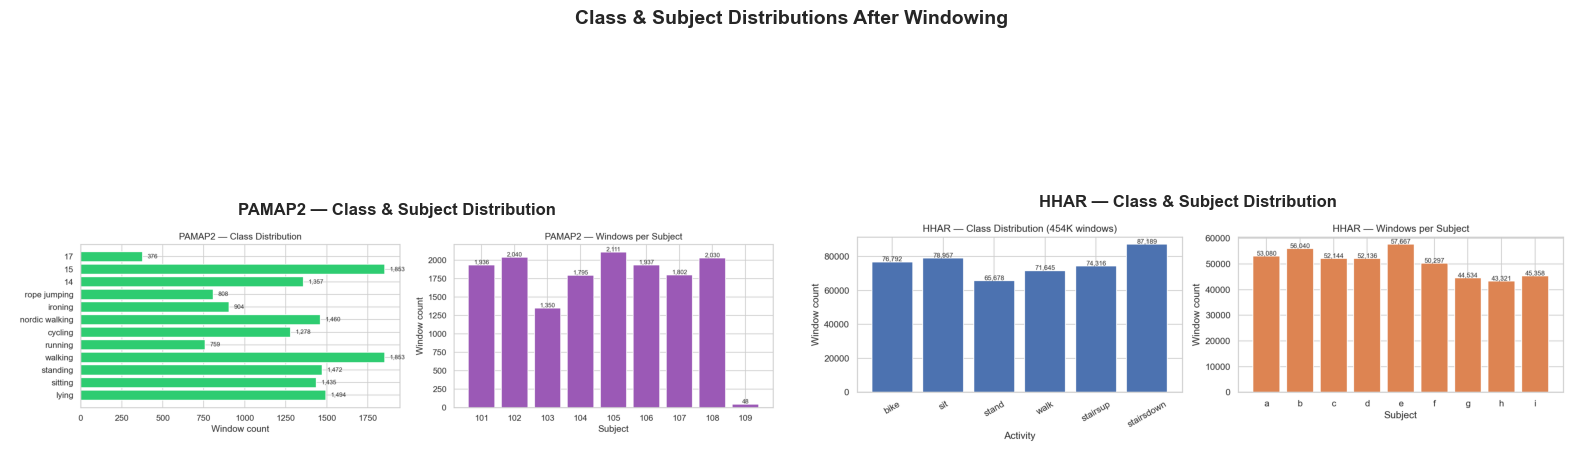


PAMAP2 class balance:
  Class  0:  1,494 windows (9.9%)
  Class  1:  1,435 windows (9.5%)
  Class  2:  1,472 windows (9.8%)
  Class  3:  1,853 windows (12.3%)
  Class  4:    759 windows (5.0%)
  Class  5:  1,278 windows (8.5%)
  Class  6:  1,460 windows (9.7%)
  Class 10:    904 windows (6.0%)
  Class 11:    808 windows (5.4%)
  Class 14:  1,357 windows (9.0%)
  Class 15:  1,853 windows (12.3%)
  Class 17:    376 windows (2.5%)

HHAR class balance:
  Class  0: 76,792 windows (16.9%)
  Class  1: 78,957 windows (17.4%)
  Class  2: 65,678 windows (14.4%)
  Class  3: 71,645 windows (15.8%)
  Class  4: 74,316 windows (16.3%)
  Class  5: 87,189 windows (19.2%)


In [5]:
# Show pre-generated class & subject distribution plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, fname, title in [
    (axes[0], 'eda_pamap2_distributions.png', 'PAMAP2 — Class & Subject Distribution'),
    (axes[1], 'eda_hhar_distributions.png',   'HHAR — Class & Subject Distribution'),
]:
    img = mpimg.imread(PLOTS / fname)
    ax.imshow(img)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle("Class & Subject Distributions After Windowing", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print quick stats
print("\nPAMAP2 class balance:")
cls, cnt = np.unique(y_p2, return_counts=True)
for c, n in zip(cls, cnt):
    print(f"  Class {c:2d}: {n:6,} windows ({n/len(y_p2)*100:.1f}%)")

print(f"\nHHAR class balance:")
cls2, cnt2 = np.unique(y_hh, return_counts=True)
for c, n in zip(cls2, cnt2):
    print(f"  Class {c:2d}: {n:6,} windows ({n/len(y_hh)*100:.1f}%)")


## Step 4: Graph Node Features Preview

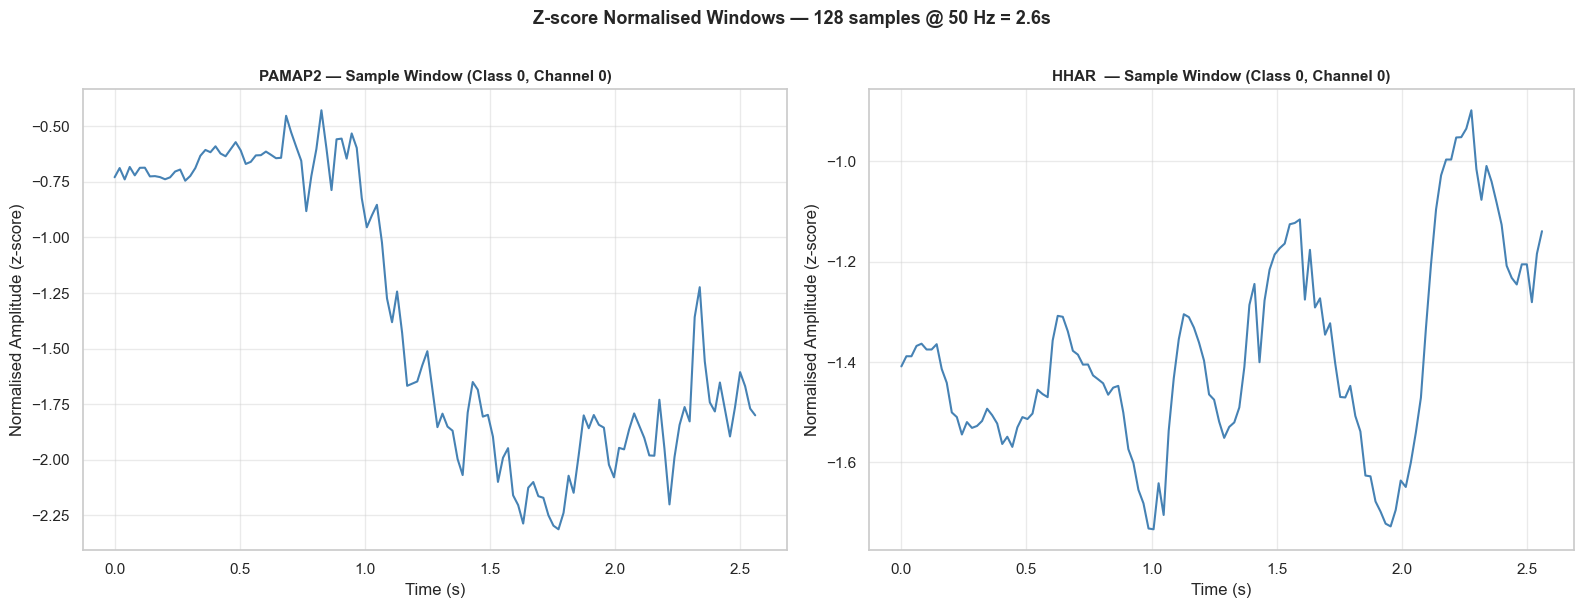


Preprocessing Pipeline — Summary
  1. Resample          : raw Hz → 50 Hz (uniform)
  2. NaN handling      : ffill → bfill (PAMAP2); drop gaps (HHAR)
  3. Normalisation     : per-channel z-score (mean=0, std=1)
  4. Windowing         : 128 samples, 50% overlap
  5. Label assignment  : majority vote within window
  6. LOSO splits       : leave-one-subject-out (9 folds each)


In [6]:
# Show raw signal sample windows for both datasets
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, X, y, title in [
    (axes[0], X_p2, y_p2, 'PAMAP2 — Sample Window (Class 0, Channel 0)'),
    (axes[1], X_hh, y_hh, 'HHAR  — Sample Window (Class 0, Channel 0)'),
]:
    idx = np.where(y == 0)[0][0]
    window = X[idx, :, 0]
    t = np.linspace(0, WINDOW_SIZE / TARGET_SAMPLING_RATE, WINDOW_SIZE)
    ax.plot(t, window, linewidth=1.5, color='steelblue')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Normalised Amplitude (z-score)')
    ax.grid(True, alpha=0.4)

plt.suptitle(f"Z-score Normalised Windows — {WINDOW_SIZE} samples @ {TARGET_SAMPLING_RATE} Hz = {WINDOW_SIZE/TARGET_SAMPLING_RATE:.1f}s",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Pipeline summary
print("\n" + "=" * 60)
print("Preprocessing Pipeline — Summary")
print("=" * 60)
print(f"  1. Resample          : raw Hz → {TARGET_SAMPLING_RATE} Hz (uniform)")
print(f"  2. NaN handling      : ffill → bfill (PAMAP2); drop gaps (HHAR)")
print(f"  3. Normalisation     : per-channel z-score (mean=0, std=1)")
print(f"  4. Windowing         : {WINDOW_SIZE} samples, {int(OVERLAP*100)}% overlap")
print(f"  5. Label assignment  : majority vote within window")
print(f"  6. LOSO splits       : leave-one-subject-out (9 folds each)")
print("=" * 60)
